In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROCESSED = Path("../data/processed")
df = pd.read_parquet(PROCESSED / "features.parquet")
print(df.shape)
df.head()

(2905, 10)


,home_form,away_form,home_fixture_density,away_fixture_density,elo_delta,home_advantage,B365H,B365D,B365A,result
0,0.0,0.0,0,0,0.047822,1,4.33,4.00,1.70,H
1,0.0,0.0,0,0,0.047822,1,2.60,3.40,2.60,H
2,0.0,0.0,0,0,0.047822,1,1.62,3.75,5.50,H
3,0.0,0.0,0,0,0.047822,1,2.50,3.30,2.80,H
4,0.0,0.0,0,0,0.047822,1,2.38,3.40,2.88,H


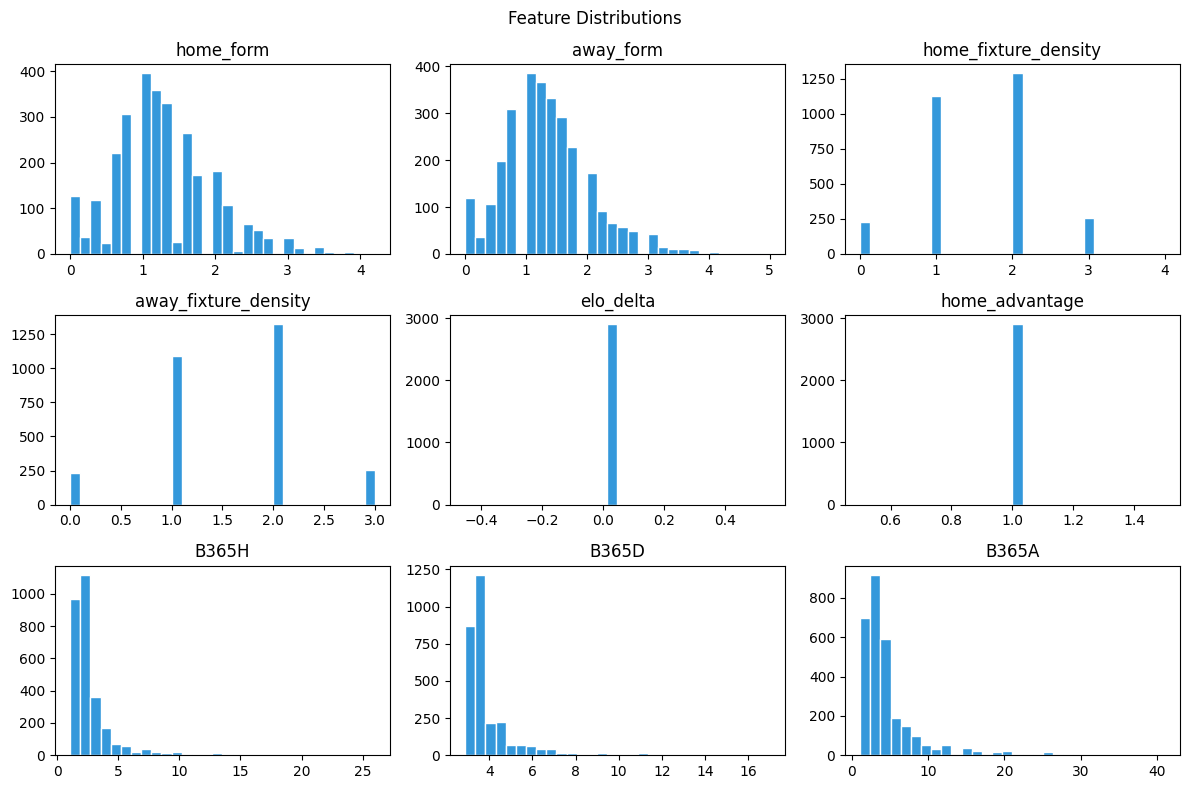

In [2]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(df.columns[:-1]):  # exclude result
    axes[i].hist(df[col].dropna(), bins=30, color="#3498db", edgecolor="white")
    axes[i].set_title(col)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

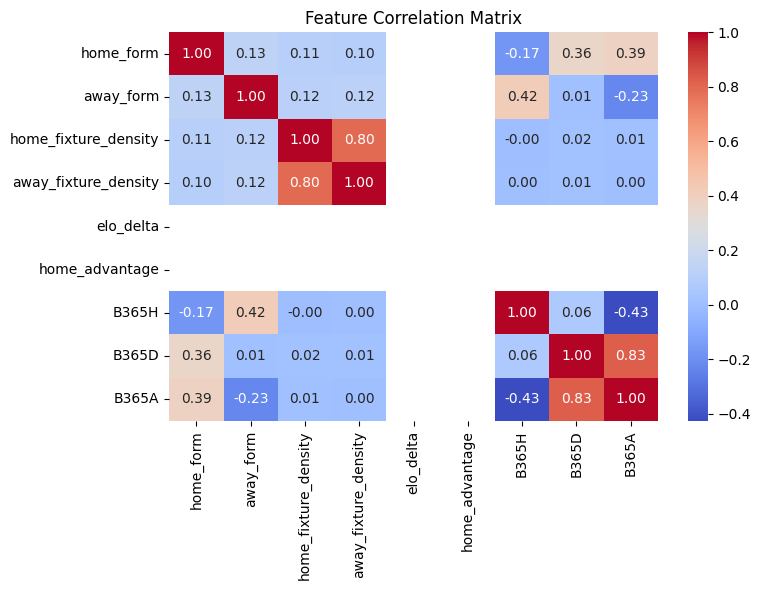

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
numeric = df.drop(columns=["result"])
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

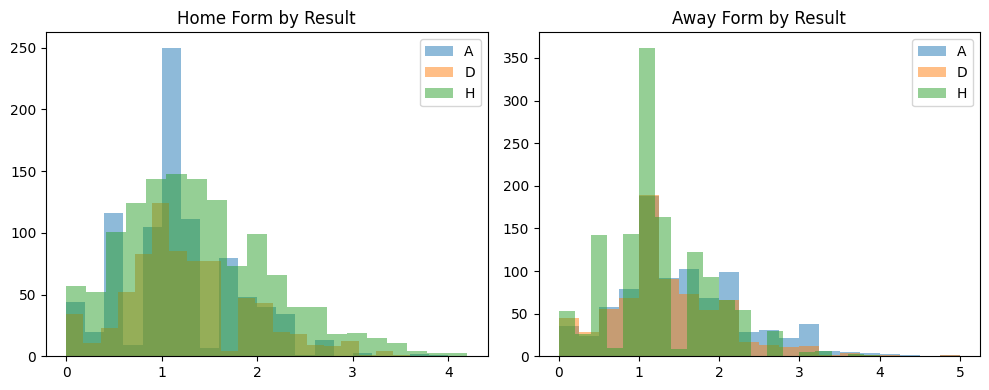

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for result, group in df.groupby("result"):
    axes[0].hist(group["home_form"], alpha=0.5, label=result, bins=20)
    axes[1].hist(group["away_form"], alpha=0.5, label=result, bins=20)
axes[0].set_title("Home Form by Result")
axes[1].set_title("Away Form by Result")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

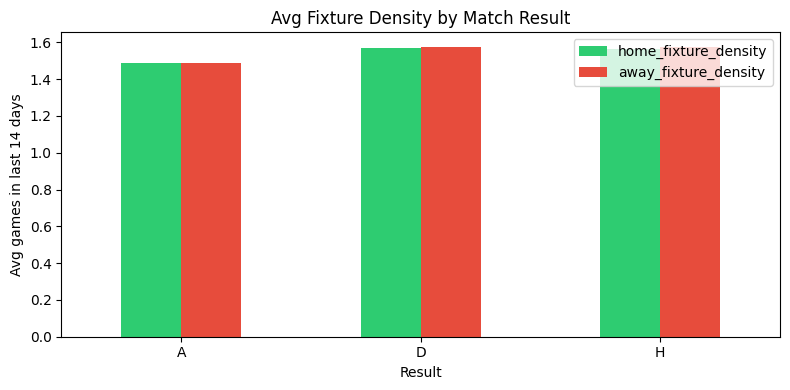

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
df.groupby("result")[["home_fixture_density", "away_fixture_density"]].mean().plot(
    kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"]
)
ax.set_title("Avg Fixture Density by Match Result")
ax.set_xlabel("Result")
ax.set_ylabel("Avg games in last 14 days")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

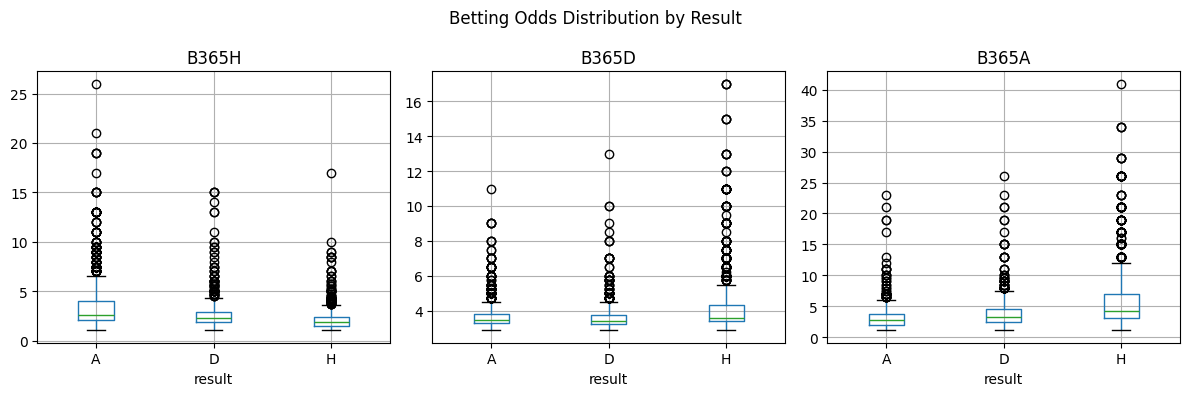

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, col in enumerate(["B365H", "B365D", "B365A"]):
    df.boxplot(column=col, by="result", ax=axes[i])
    axes[i].set_title(col)
plt.suptitle("Betting Odds Distribution by Result")
plt.tight_layout()
plt.show()

In [7]:
print("Feature summary:")
print(df.groupby("result").mean().round(3))

Feature summary:
        home_form  away_form  home_fixture_density  away_fixture_density  \
result                                                                     
A           1.159      1.503                 1.486                 1.490   
D           1.273      1.316                 1.572                 1.576   
H           1.407      1.231                 1.564                 1.572   

        elo_delta  home_advantage  B365H  B365D  B365A  
result                                                  
A           0.048             1.0  3.720  3.751  3.121  
D           0.048             1.0  2.679  3.703  4.030  
H           0.048             1.0  2.111  4.264  6.119  
